In [17]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from scipy.stats import multivariate_normal as mvn
from sklearn.mixture import GaussianMixture

In [44]:
def calculate_posterior(px, pi):
    """
    
    """
    weighted_px = px * pi  # broadcasting pi over rows of px

    # Denominator: sum over components for each data point i
    denom = weighted_px.sum(axis=1)  # shape (n,)

    # Posterior (responsibilities), shape (n, K)
    gamma = weighted_px / denom[:, np.newaxis]
    return gamma

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

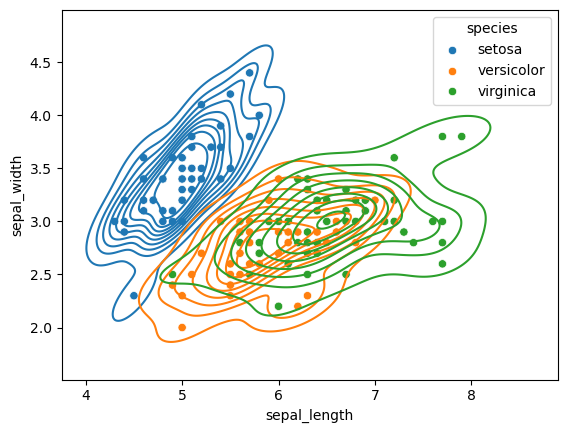

In [3]:
# Load the iris dataset
iris = sns.load_dataset('iris')


sns.kdeplot(data=iris,
            x='sepal_length',
            y='sepal_width',
            hue='species',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',hue='species',)

/opt/miniconda3/envs/ds/lib/python3.11/site-packages/seaborn/distributions.py:1128: UserWarning: cmap parameter ignored when using hue mapping.
  warnings.warn(msg, UserWarning)


<Axes: xlabel='sepal_length', ylabel='petal_length'>

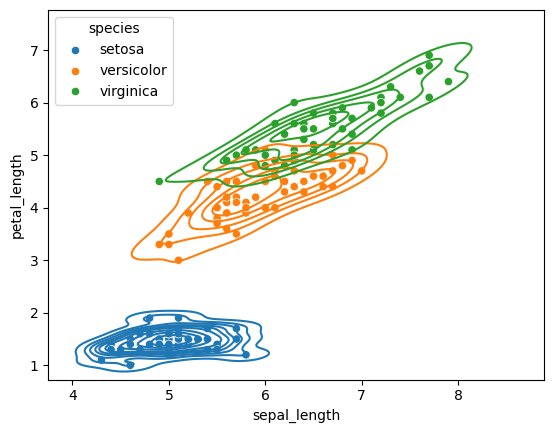

In [5]:
sns.kdeplot(data=iris,
            x='sepal_length',
            y='petal_length',
            hue='species',
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(data=iris, x='sepal_length', y='petal_length',hue='species',)

In [6]:
from sklearn.mixture import GaussianMixture

In [10]:
# For multivariate data (e.g., eruptions and waiting)
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(iris.iloc[:,:4])

GaussianMixture(n_components=3, random_state=0)

In [11]:
# Accessing the parameters
means = gmm.means_
covariances = gmm.covariances_
weights = gmm.weights_

print("Means:\n", means)
print("\nCovariances:\n", covariances)
print("\nMixing Proportions:\n", weights)

Means:
 [[5.9170732  2.77804839 4.20540364 1.29848217]
 [5.006      3.428      1.462      0.246     ]
 [6.54639415 2.94946365 5.48364578 1.98726565]]

Covariances:
 [[[0.2755171  0.09662295 0.18547072 0.05478901]
  [0.09662295 0.09255152 0.09103431 0.04299899]
  [0.18547072 0.09103431 0.20235849 0.06171383]
  [0.05478901 0.04299899 0.06171383 0.03233775]]

 [[0.121765   0.097232   0.016028   0.010124  ]
  [0.097232   0.140817   0.011464   0.009112  ]
  [0.016028   0.011464   0.029557   0.005948  ]
  [0.010124   0.009112   0.005948   0.010885  ]]

 [[0.38744093 0.09223276 0.30244302 0.06087397]
  [0.09223276 0.11040914 0.08385112 0.05574334]
  [0.30244302 0.08385112 0.32589574 0.07276776]
  [0.06087397 0.05574334 0.07276776 0.08484505]]]

Mixing Proportions:
 [0.30127092 0.33333333 0.36539575]


In [13]:
iris.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


4

,sepal_length,sepal_width,petal_length,petal_width
36,5.5,3.5,1.3,0.2
5,5.4,3.9,1.7,0.4
53,5.5,2.3,4.0,1.3


In [83]:
### Initialize


# Extract the 2D data (eruptions and waiting).
X = iris.iloc[:,:4].to_numpy()

mu1_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))
mu2_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))
mu3_hat = np.array(list(iris.iloc[:,:4].sample(1).iloc[0]))

# Initialize two covariance matrices as identity for simplicity.
Sigma1_hat = np.eye(X.shape[1])
Sigma2_hat = np.eye(X.shape[1])
Sigma3_hat = np.eye(X.shape[1])

# Mixing proportions (still scalars).
pi1_hat = 1/3
pi2_hat = 1/3
pi3_hat = 1/3

In [84]:
epoch_log_likelihood = {}

for i in range(50):

    px_class1 = [mvn(mean=mu1_hat, cov=Sigma1_hat).pdf(xi) for xi in X]
    px_class2 = [mvn(mean=mu2_hat, cov=Sigma2_hat).pdf(xi) for xi in X]
    px_class3 = [mvn(mean=mu3_hat, cov=Sigma3_hat).pdf(xi) for xi in X]

    px_class1 = np.array(px_class1)  # convert list to array
    px_class2 = np.array(px_class2)
    px_class3 = np.array(px_class3)   

    log_likelihood = np.sum(
    np.log( ( 
                pi1_hat * px_class1) + (pi2_hat * px_class2) + (pi3_hat * px_class3) 
            )
        )

    epoch_log_likelihood[i] = log_likelihood

    px = np.column_stack([px_class1, px_class2, px_class3])
    # Now px.shape == (n, 3)

    pi = np.array([pi1_hat, pi2_hat, pi3_hat])   # shape (3,)

    posteriors = calculate_posterior(px, pi)

    ## Maximization step

    ### Cluster 1
    posteriors_class1 = posteriors[:,0]

    # 1) Mean
    N1 = posteriors_class1.sum()
    mu1_hat = (X * posteriors_class1[:, None]).sum(axis=0) / N1

    # 2) Covariance
    diff1 = X - mu1_hat
    Sigma1_hat = (posteriors_class1[:, None] * diff1).T @ diff1 / N1
    ############################################################################################################

    ### Cluster 2
    posteriors_class2 = posteriors[:,1]

    # 1) Mean
    N2 = posteriors_class2.sum()
    mu2_hat = (X * posteriors_class2[:, None]).sum(axis=0) / N2

    # 2) Covariance
    diff2 = X - mu2_hat
    Sigma2_hat = (posteriors_class2[:, None] * diff2).T @ diff2 / N2
    ############################################################################################################

    ### Cluster 3
    posteriors_class3 = posteriors[:,2]

    # 1) Mean
    N3 = posteriors_class3.sum()
    mu3_hat = (X * posteriors_class3[:, None]).sum(axis=0) / N3

    # 2) Covariance
    diff3 = X - mu3_hat
    Sigma3_hat = (posteriors_class3[:, None] * diff3).T @ diff3 / N3
    ############################################################################################################

    pi1_hat = sum(posteriors_class1) / len(X)
    pi2_hat = sum(posteriors_class2) / len(X)
    pi3_hat = sum(posteriors_class3) / len(X)


In [87]:
print("mu1_hat =", mu1_hat)
print("mu2_hat =", mu2_hat)
print("mu3_hat =", mu3_hat)

mu1_hat = [5.006 3.428 1.462 0.246]
mu2_hat = [5.91496959 2.77784365 4.20155323 1.29696685]
mu3_hat = [6.54454865 2.94866115 5.47955343 1.98460495]


In [88]:
gmm.means_

array([[5.9170732 , 2.77804839, 4.20540364, 1.29848217],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.54639415, 2.94946365, 5.48364578, 1.98726565]])

In [89]:
print("Sigma1_hat =", Sigma1_hat)
print("Sigma2_hat =", Sigma2_hat)
print("Sigma3_hat =", Sigma3_hat)

Sigma1_hat = [[0.121764 0.097232 0.016028 0.010124]
 [0.097232 0.140816 0.011464 0.009112]
 [0.016028 0.011464 0.029556 0.005948]
 [0.010124 0.009112 0.005948 0.010884]]
Sigma2_hat = [[0.27531878 0.09694138 0.18466239 0.05439074]
 [0.09694138 0.09264604 0.09114317 0.04299735]
 [0.18466239 0.09114317 0.20063041 0.06097847]
 [0.05439074 0.04299735 0.06097847 0.03199695]]
Sigma3_hat = [[0.38704429 0.09220792 0.30281173 0.06165105]
 [0.09220792 0.1103377  0.08428758 0.0560115 ]
 [0.30281173 0.08428758 0.32779736 0.07453004]
 [0.06165105 0.0560115  0.07453004 0.08579773]]


In [90]:
gmm.covariances_

array([[[0.2755171 , 0.09662295, 0.18547072, 0.05478901],
        [0.09662295, 0.09255152, 0.09103431, 0.04299899],
        [0.18547072, 0.09103431, 0.20235849, 0.06171383],
        [0.05478901, 0.04299899, 0.06171383, 0.03233775]],

       [[0.121765  , 0.097232  , 0.016028  , 0.010124  ],
        [0.097232  , 0.140817  , 0.011464  , 0.009112  ],
        [0.016028  , 0.011464  , 0.029557  , 0.005948  ],
        [0.010124  , 0.009112  , 0.005948  , 0.010885  ]],

       [[0.38744093, 0.09223276, 0.30244302, 0.06087397],
        [0.09223276, 0.11040914, 0.08385112, 0.05574334],
        [0.30244302, 0.08385112, 0.32589574, 0.07276776],
        [0.06087397, 0.05574334, 0.07276776, 0.08484505]]])

In [91]:
print("pi1_hat =", pi1_hat)
print("pi2_hat =", pi2_hat)
print("pi3_hat =", pi3_hat)

pi1_hat = 0.3333333333333333
pi2_hat = 0.299193187736276
pi3_hat = 0.3674734789303908


In [92]:
gmm.weights_

array([0.30127092, 0.33333333, 0.36539575])